In [20]:
!pip install osmnx
!pip install tqdm
!pip install geopandas


In [21]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Polygon
from shapely.geometry import Point

#Файлы ПВЗ,арендные места, точки 
pvz = pd.read_excel("data/pvz.xlsx")
rent_places = pd.read_excel("data/rent_places.xlsx")


poi = gpd.read_file("data/poi-point.geojson")
transport = gpd.read_file("data/public-transport-point.geojson")

# Выводим первые строки
print("PVZ:")
print(pvz.head())

print("\nАрендные места:")
print(rent_places.head())

print("\nPOI:")
print(poi.head())

print("\nОстановки транспорта:")
print(transport.head())

print("\nЖилые здания:")
print(buildings.head())


PVZ:
         ID                   Address Square  Rating        lat       long
0  50016316        Зелёная улица, 230   34.9   4.993  45.145918  39.051427
1    217006      Зелёная улица, 174\n  88.31   4.982  45.142911  39.045040
2    161947      Зелёная улица, 108\n     69   4.982  45.122990  39.166843
3    325506  Земляничная улица, 122\n     64   4.985  45.139224  39.032563
4    112779         Вишнёвая улица, 2     86   4.990  45.144678  39.038761

Арендные места:
     ID                           Address  square  rent_price        lat  \
0  1001  улица имени В.М. Бехтерева, 2Ак1      45       35000  45.158910   
1  1002      улица Археолога Анфимова, 39     100       50000  45.156330   
2  1003         Екатерининская улица, 1к1      37       40000  45.162380   
3  1004               Северная улица, 12А     120       96000  45.157436   
4  1005              Советская улица, 2/1      50       40000  45.151512   

        long  
0  38.964398  
1  38.959566  
2  39.012378  
3  39.00707

In [22]:
import geopandas as gpd


# Фильтрация POI (оставляем только важные категории)
important_poi = poi[poi["AMENITY"].isin(["cafe", "restaurant", "bank", "pharmacy", "supermarket"])]

# Фильтрация общественного транспорта (только автобусные и трамвайные остановки)
filtered_transport = transport[transport["HIGHWAY"].eq("bus_stop") | transport["RAILWAY"].eq("tram_stop")]


# Сохранение отфильтрованных данных
important_poi.to_file("filtered_poi.geojson", driver="GeoJSON")
filtered_transport.to_file("filtered_transport.geojson", driver="GeoJSON")



In [23]:

# Очистка данных
pvz = pvz[["ID", "Address", "Square", "Rating", "long", "lat"]]
rent_places = rent_places[["ID", "Address", "square", "rent_price", "long", "lat"]]
poi = poi[["NAME", "geometry"]]
transport = transport[["NAME", "geometry"]]


# Проверка CRS (системы координат)
print("PVZ CRS:", "WGS84 ")
print("Rent Places CRS:", "WGS84 ")
print("POI CRS:", poi.crs)
print("Transport CRS:", transport.crs)


# Преобразуем в GeoDataFrame
pvz["geometry"] = pvz.apply(lambda row: Point(row["long"], row["lat"]), axis=1)
rent_places["geometry"] = rent_places.apply(lambda row: Point(row["long"], row["lat"]), axis=1)

pvz = gpd.GeoDataFrame(pvz, geometry="geometry", crs="EPSG:4326")
rent_places = gpd.GeoDataFrame(rent_places, geometry="geometry", crs="EPSG:4326")

# Приводим все данные к единой CRS (если нужно)
if poi.crs != "EPSG:4326":
    poi = poi.to_crs("EPSG:4326")
if transport.crs != "EPSG:4326":
    transport = transport.to_crs("EPSG:4326")


# Сохранение очищенных данных
pvz.to_file("cleaned_pvz.geojson", driver="GeoJSON")
rent_places.to_file("cleaned_rent_places.geojson", driver="GeoJSON")
poi.to_file("cleaned_poi.geojson", driver="GeoJSON")
transport.to_file("cleaned_transport.geojson", driver="GeoJSON")




PVZ CRS: WGS84 
Rent Places CRS: WGS84 
POI CRS: EPSG:4326
Transport CRS: EPSG:4326


In [24]:


# Определяем название города
city_name = "Krasnodar, Russia"

# Загружаем дорожную сеть
G = ox.graph_from_place(city_name, network_type="drive")

# Преобразуем граф дорог в GeoDataFrame
roads_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True)

# Сохраняем в GeoJSON
roads_gdf.to_file("roads_krasnodar.geojson", driver="GeoJSON")

print("Файл roads_krasnodar.geojson сохранен!")


/Users/arslan/anaconda3/envs/geo_env2/lib/python3.11/site-packages/osmnx/_overpass.py:267: UserWarning: This area is 46 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Файл roads_krasnodar.geojson сохранен!


In [25]:
import pandas as pd
import geopandas as gpd



def convert_excel_to_geojson(input_file, output_file, lon_col, lat_col):
    df = pd.read_excel(input_file)
    
    # Создаем геометрические точки
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"  # WGS 84
    )
    
    # Сохраняем в GeoJSON
    gdf.to_file(output_file, driver="GeoJSON")
    print(f"Файл {output_file} сохранен!")

convert_excel_to_geojson("data/pvz.xlsx", "pvz.geojson", "long", "lat")

convert_excel_to_geojson("data/rent_places.xlsx", "rent_places.geojson", "long", "lat")


Файл pvz.geojson сохранен!
Файл rent_places.geojson сохранен!


Skipping field highway: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


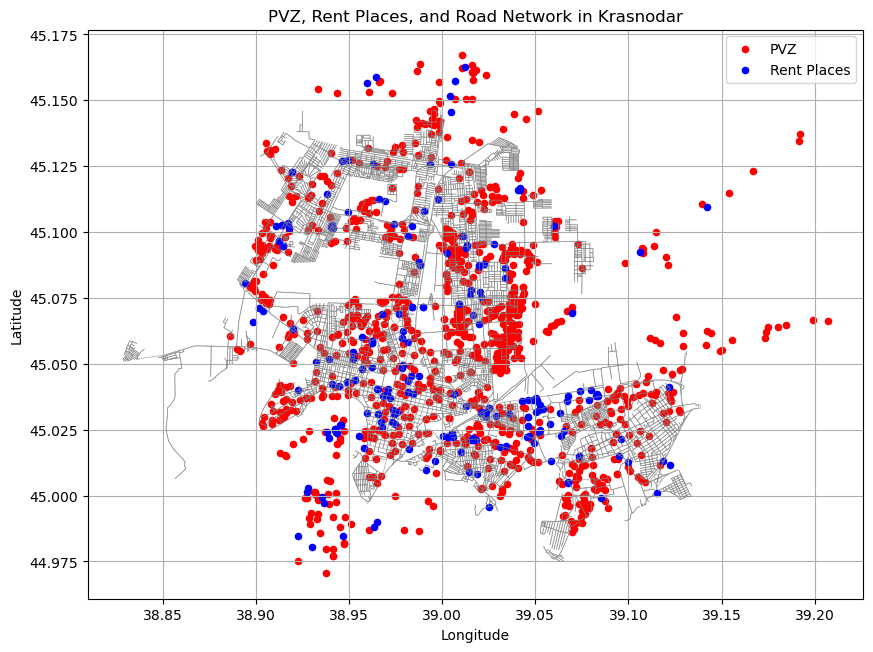

In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Загружаем данные
roads_gdf = gpd.read_file("roads_krasnodar.geojson")  # Дороги
pvz_gdf = gpd.read_file("pvz.geojson")  # ПВЗ
rent_gdf = gpd.read_file("rent_places.geojson")  # Арендные места

# Создаем карту
fig, ax = plt.subplots(figsize=(10, 10))

# отображение дороги
roads_gdf.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.7)


pvz_gdf.plot(ax=ax, color="red", markersize=20, label="PVZ")


rent_gdf.plot(ax=ax, color="blue", markersize=20, label="Rent Places")


plt.legend()
plt.title("PVZ, Rent Places, and Road Network in Krasnodar")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

# Показываем карту
plt.show()


In [28]:
import geopandas as gpd


pvz_gdf = gpd.read_file("pvz.geojson").to_crs(epsg=3857)
rent_gdf = gpd.read_file("rent_places.geojson").to_crs(epsg=3857)
hex_gdf = gpd.read_file("krasnodar_hex_grid_updated.geojson").to_crs(epsg=3857)

# определяем, в каком гексагоне находится каждая точка)
pvz_gdf = gpd.sjoin(pvz_gdf, hex_gdf, how="left", predicate="within")
rent_gdf = gpd.sjoin(rent_gdf, hex_gdf, how="left", predicate="within")

# Сохраняем обновленные файлы
pvz_gdf.to_file("pvz_updated.geojson", driver="GeoJSON")
rent_gdf.to_file("rent_places_updated.geojson", driver="GeoJSON")




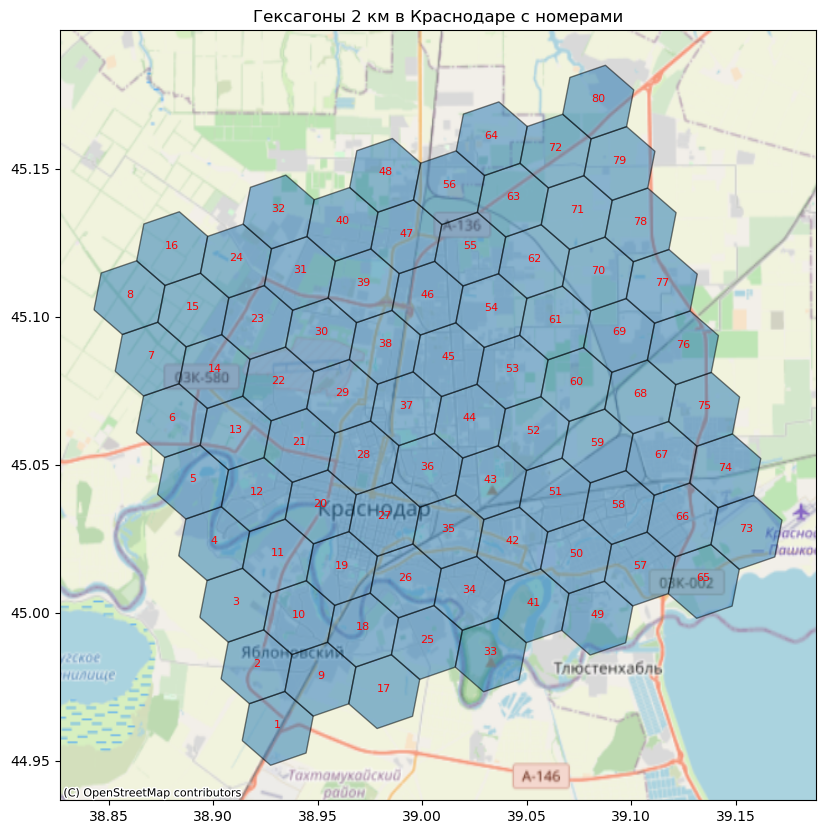

In [29]:

#Границы краснодара
krasnodar_bounds = {
    "xmin": 38.862, "ymin": 44.9815,
    "xmax": 39.132, "ymax": 45.13815  # Примерные границы
}

# 2  размер гексагона (2 км)
hex_size = 2000  # в метрах

# 
gdf_bounds = gpd.GeoDataFrame(
    geometry=[Polygon([
        (krasnodar_bounds["xmin"], krasnodar_bounds["ymin"]),
        (krasnodar_bounds["xmax"], krasnodar_bounds["ymin"]),
        (krasnodar_bounds["xmax"], krasnodar_bounds["ymax"]),
        (krasnodar_bounds["xmin"], krasnodar_bounds["ymax"])
    ])], crs="EPSG:4326"
).to_crs(epsg=3857)

xmin, ymin, xmax, ymax = gdf_bounds.total_bounds

from shapely.affinity import rotate

# шестиугольная сетка 
hexagons = []
hex_ids = []  
dx = hex_size * 3/2
dy = np.sqrt(3) * hex_size
offset = dy / 2  

row = 0
hex_id = 1  
for x in np.arange(xmin + hex_size / 2, xmax, dx):  
    for y in np.arange(ymin, ymax, dy):
        y_shifted = y + (offset if row % 2 else 0)
        hexagon = Polygon([
            (x, y_shifted),
            (x + hex_size / 2, y_shifted + dy / 2),
            (x + hex_size * 3 / 2, y_shifted + dy / 2),
            (x + 2 * hex_size, y_shifted),
            (x + hex_size * 3 / 2, y_shifted - dy / 2),
            (x + hex_size / 2, y_shifted - dy / 2),
            (x, y_shifted)
        ])

        if gdf_bounds.geometry.iloc[0].intersects(hexagon):
            hexagons.append(hexagon)
            hex_ids.append(hex_id)
            hex_id += 1

    row += 1

# Создаём GeoDataFrame для всей сетки
hex_gdf = gpd.GeoDataFrame(geometry=hexagons, crs="EPSG:3857")

# Поворачиваем ВСЮ сетку разом на 15 градусов вокруг центра Краснодара
center = gdf_bounds.geometry.centroid.iloc[0]  # Центр области
hex_gdf["geometry"] = hex_gdf["geometry"].apply(lambda geom: rotate(geom, 19, origin=center))

# Преобразуем обратно в WGS84 (широта/долгота)
hex_gdf = hex_gdf.to_crs(epsg=4326)

# Добавляем ID и сохраняем
hex_gdf["id"] = hex_ids  
hex_gdf.to_file("krasnodar_hex_grid_last.geojson", driver="GeoJSON")
hex_gdf.to_csv("krasnodar_hex_grid_last.csv", index=False)


#  Визуализация с номерами на полигонах
fig, ax = plt.subplots(figsize=(10, 10))
hex_gdf.plot(ax=ax, edgecolor="k", alpha=0.5)
ctx.add_basemap(ax, crs=hex_gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Наложим ID на гексагоны
for idx, row in hex_gdf.iterrows():
    ax.text(row['geometry'].centroid.x, row['geometry'].centroid.y, str(row['id']),
            fontsize=8, ha='center', color='red')

plt.title("Гексагоны 2 км в Краснодаре с номерами")
plt.show()


In [30]:
import geopandas as gpd
import pandas as pd

# 
hex_gdf = gpd.read_file("krasnodar_hex_grid_last.geojson")

#  данные о населении и трафике
data_df = pd.read_excel("data/гексагоны_1.xlsx")

# Объединяем по 'id'
hex_gdf = hex_gdf.merge(data_df, on="id", how="left")


hex_gdf.to_file("krasnodar_hex_grid_updated.geojson", driver="GeoJSON")




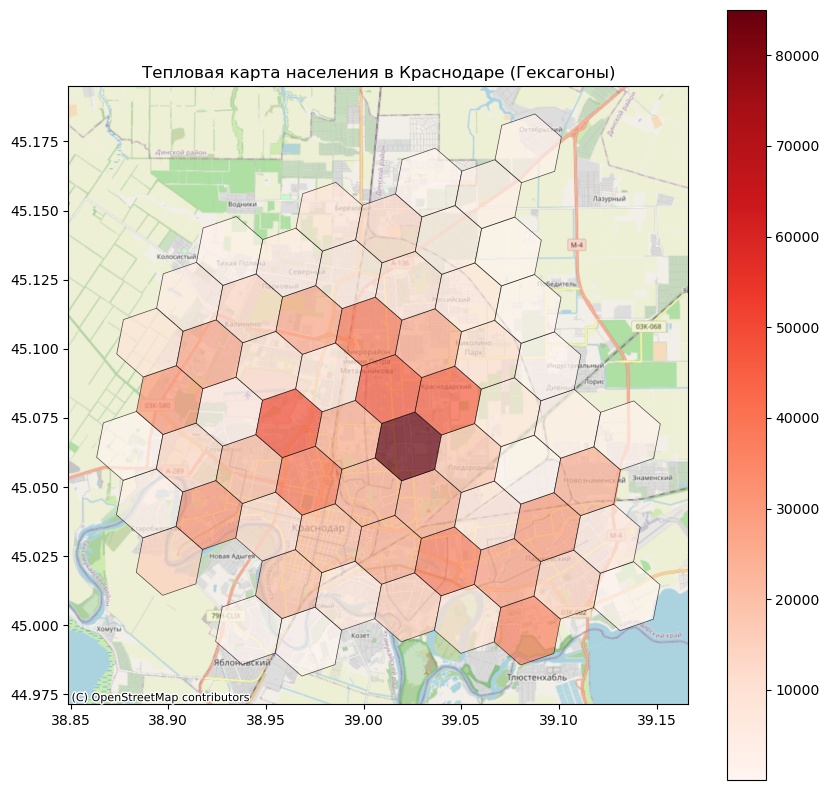

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

#  Загружаем обновленный GeoJSON
hex_gdf = gpd.read_file("krasnodar_hex_grid_updated.geojson")

# 2️⃣ Проверяем, что колонка с населением есть
population_column = "population"  # Название колонки с населением в файле
if population_column not in hex_gdf.columns:
    raise ValueError(f"Колонка '{population_column}' не найдена в GeoJSON!")

# гексагоны с градиентом по населению
fig, ax = plt.subplots(figsize=(10, 10))
hex_gdf.plot(column=population_column, cmap="Reds", edgecolor="k", alpha=0.7, linewidth=0.5, legend=True, ax=ax)

# 
ctx.add_basemap(ax, crs=hex_gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

plt.title("Тепловая карта населения в Краснодаре (Гексагоны)")
plt.show()


              NAME NAME_EN NAME_RU      MAN_MADE LEISURE         AMENITY  \
0  город Краснодар    None    None          None    None  ferry_terminal   
1             None    None    None  surveillance    None            None   
2           Дворик    None    None          None    None            cafe   
3        Будда-бар    None    None          None    None             bar   
4    Леди Мармелад    None    None          None    None            cafe   

  OFFICE  SHOP TOURISM SPORT OSM_TYPE     OSM_ID                   geometry  
0   None  None    None  None     node  295158959  POINT (38.98457 45.01123)  
1   None  None    None  None     node  295177628  POINT (39.09422 45.06611)  
2   None  None    None  None     node  295180470   POINT (38.9777 45.04333)  
3   None  None    None  None     node  295180502  POINT (38.97797 45.04359)  
4   None  None    None  None     node  295180519  POINT (38.97753 45.04283)  
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10725 entries, 0 

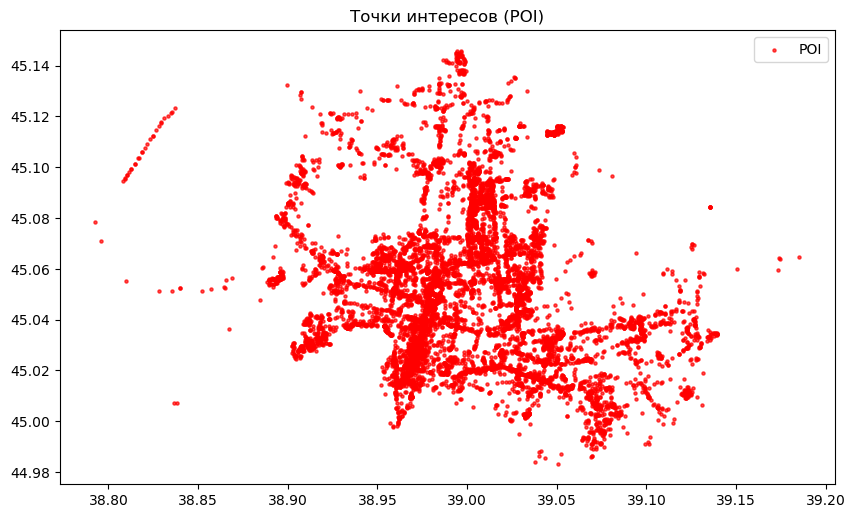

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt


poi_gdf = gpd.read_file("data/poi-point.geojson")


print(poi_gdf.head())


print(poi_gdf.info())

# Визуализация точек POI
fig, ax = plt.subplots(figsize=(10, 10))
poi_gdf.plot(ax=ax, color="red", markersize=5, alpha=0.7, label="POI")
plt.legend()
plt.title("Точки интересов (POI)")
plt.show()


In [33]:
import geopandas as gpd

pvz_gdf = gpd.read_file("pvz_updated.geojson").to_crs(epsg=3857)
poi_gdf = gpd.read_file("data/poi-point.geojson").to_crs(epsg=3857)
rent_gdf = gpd.read_file("rent_places_updated.geojson").to_crs(epsg=3857)

radius = 500

pvz_gdf["buffer"] = pvz_gdf.geometry.buffer(radius)

# Подсчитываем POI внутри каждой буферной зоны
poi_counts = pvz_gdf["buffer"].apply(lambda buf: poi_gdf[poi_gdf.geometry.within(buf)].shape[0])

# Добавляем количество POI как новый столбец
pvz_gdf["poi_count"] = poi_counts

pvz_gdf = pvz_gdf.drop(columns=["buffer"])

pvz_gdf.to_file("pvz_with_poi.geojson", driver="GeoJSON")
print("Файл сохранен: pvz_with_poi.geojson")

rent_gdf["buffer"] = rent_gdf.geometry.buffer(radius)

# Считаем, сколько POI попадает в каждую буферную зону арендуемых мест
rent_poi_counts = rent_gdf["buffer"].apply(lambda buf: poi_gdf[poi_gdf.geometry.within(buf)].shape[0])

# Добавляем колонку с количеством POI
rent_gdf["poi_count"] = rent_poi_counts

rent_gdf = rent_gdf.drop(columns=["buffer"])
rent_gdf.to_file("rent_places_with_poi.geojson", driver="GeoJSON")

Файл сохранен: pvz_with_poi.geojson


In [34]:
import geopandas as gpd
import pandas as pd

pvz_gdf = gpd.read_file("pvz_with_poi.geojson")
rent_gdf = gpd.read_file("rent_places_with_poi.geojson")

pvz_gdf = pvz_gdf.to_crs(epsg=4326)
rent_gdf = rent_gdf.to_crs(epsg=4326)


pvz_gdf = pvz_gdf[["ID", "Address", "lat", "long", "population", "Pedestrian traffic", "car traffic", "poi_count", "geometry"]]
rent_gdf = rent_gdf[["ID", "Address", "lat", "long", "square", "rent_price", "population", "poi_count", "geometry"]]

# Заполняем пропущенные значения нулями
pvz_gdf.fillna(0, inplace=True)
rent_gdf.fillna(0, inplace=True)

pvz_gdf.to_file("cleaned_pvz.geojson", driver="GeoJSON")
rent_gdf.to_file("cleaned_rent_places.geojson", driver="GeoJSON")


In [35]:
import geopandas as gpd
import pandas as pd
# тип объекта
pvz_gdf["type"] = "pvz"
rent_gdf["type"] = "rent"
# Объединяем в один DataFrame
all_places = gpd.GeoDataFrame(pd.concat([pvz_gdf, rent_gdf], ignore_index=True))

# Сохраняем объединенный файл
all_places.to_file("all_places.geojson", driver="GeoJSON")

print("Файл объединен и сохранен: all_places.geojson")


Файл объединен и сохранен: all_places.geojson


In [36]:
import geopandas as gpd

# # Загружаем данные
hexagons = gpd.read_file("krasnodar_hex_grid_updated.geojson")


# Приводим к одной проекции
hexagons = hexagons.to_crs(epsg=3857)
pvz_gdf = pvz_gdf.to_crs(epsg=3857)
rent_gdf = rent_gdf.to_crs(epsg=3857)

# Оставляем только те точки которые находятся внутри гексагонов
pvz_gdf = pvz_gdf[pvz_gdf.geometry.within(hexagons.unary_union)]
rent_gdf = rent_gdf[rent_gdf.geometry.within(hexagons.unary_union)]

pvz_gdf.to_file("filtered_last_pvz.geojson", driver="GeoJSON")
rent_gdf.to_file("filtered_last_rent.geojson", driver="GeoJSON")



/var/folders/9y/wsk01vn97ssf438dvj6xsw640000gn/T/ipykernel_69022/3199337774.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pvz_gdf = pvz_gdf[pvz_gdf.geometry.within(hexagons.unary_union)]
/var/folders/9y/wsk01vn97ssf438dvj6xsw640000gn/T/ipykernel_69022/3199337774.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rent_gdf = rent_gdf[rent_gdf.geometry.within(hexagons.unary_union)]


In [37]:
import geopandas as gpd
import pandas as pd

# Загружаем данные
pvz_gdf = gpd.read_file("filtered_last_pvz.geojson")
rent_gdf = gpd.read_file("filtered_last_rent.geojson")
hex_gdf = gpd.read_file("krasnodar_hex_grid_updated.geojson")
hex_gdf = hex_gdf.to_crs(epsg=3857)
pvz_gdf = pvz_gdf.to_crs(epsg=3857)
rent_gdf = rent_gdf.to_crs(epsg=3857)
# Добавляем столбец type для pvz
pvz_gdf["type"] = "pvz"


# Присоединяем гексагоны к ПВЗ
pvz_gdf = pvz_gdf.sjoin(hex_gdf, how="left", predicate="within")
pvz_gdf = pvz_gdf[['ID', 'geometry', 'id', 'type', 'population_right', 
                   'Pedestrian traffic_right', 'car traffic_right', 'poi_count']]
pvz_gdf = pvz_gdf.rename(columns={'population_right': 'population',
                                   'Pedestrian traffic_right': 'Pedestrian traffic',
                                   'car traffic_right': 'car traffic'})


# Присоединяем гексагоны к аренде
rent_gdf = rent_gdf.sjoin(hex_gdf, how="left", predicate="within")
rent_gdf = rent_gdf[['ID', 'Address', 'lat', 'long', 'square', 'rent_price', 
                     'population_right', 'Pedestrian traffic', 'car traffic', 
                     'poi_count', 'geometry', 'type']]

rent_gdf = rent_gdf.rename(columns={'population_right': 'population'})


# Объединяем данные
total_gdf = gpd.GeoDataFrame(pd.concat([pvz_gdf, rent_gdf], ignore_index=True))




In [38]:
import geopandas as gpd
import pandas as pd
pvz_gdf = gpd.read_file("filtered_last_pvz.geojson")
rent_gdf = gpd.read_file("filtered_last_rent.geojson")
hex_gdf = gpd.read_file("krasnodar_hex_grid_updated.geojson")
hex_gdf = hex_gdf.to_crs(epsg=3857)
pvz_gdf = pvz_gdf.to_crs(epsg=3857)
rent_gdf = rent_gdf.to_crs(epsg=3857)
print("PVZ Data:")
print(pvz_gdf.head(), "\n", pvz_gdf.crs, "\n", pvz_gdf.dtypes)

print("\nRent Data:")
print(rent_gdf.head(), "\n", rent_gdf.crs, "\n", rent_gdf.dtypes)

print("\nHexagon Grid Data:")
print(hex_gdf.head(), "\n", hex_gdf.crs, "\n", hex_gdf.dtypes)


PVZ Data:
         ID                   Address        lat       long  population  \
0  50016316        Зелёная улица, 230  45.145918  39.051427      4200.0   
1    217006      Зелёная улица, 174\n  45.142911  39.045040      4200.0   
2    325506  Земляничная улица, 122\n  45.139224  39.032563      4200.0   
3    112779         Вишнёвая улица, 2  45.144678  39.038761      4200.0   
4    314626       Ореховая улица, 621  45.134188  39.019627     12000.0   

   Pedestrian traffic  car traffic  poi_count type  \
0              3200.0      11000.0          0  pvz   
1              3200.0      11000.0          0  pvz   
2              3200.0      11000.0          0  pvz   
3              3200.0      11000.0          0  pvz   
4             13000.0      23000.0          1  pvz   

                          geometry  
0  POINT (4347184.968 5644522.615)  
1  POINT (4346473.971 5644048.027)  
2   POINT (4345085.038 5643466.15)  
3  POINT (4345774.996 5644326.906)  
4  POINT (4343645.009 5642671

In [39]:
print("\nHexagon Grid Data:")
print(hex_gdf.head(), "\n", hex_gdf.crs, "\n", hex_gdf.dtypes)


Hexagon Grid Data:
   id                                         geometry_y  population  \
0   1  POLYGON ((38.91394910119737 44.95674787581145,...         NaN   
1   2  POLYGON ((38.90381789091554 44.977565122039785...         NaN   
2   3  POLYGON ((38.893686680633714 44.99837481341240...         NaN   
3   4  POLYGON ((38.883555470351894 45.01917694992701...     15000.0   
4   5  POLYGON ((38.873424260070074 45.03997153158528...      3000.0   

   Pedestrian traffic  car traffic  \
0                 NaN          NaN   
1                 NaN          NaN   
2                 NaN          NaN   
3             11000.0       3800.0   
4              2600.0      12000.0   

                                            geometry  
0  POLYGON ((4331880.999 5614714.893, 4332262.617...  
1  POLYGON ((4330753.198 5617990.265, 4331134.816...  
2  POLYGON ((4329625.396 5621265.637, 4330007.014...  
3  POLYGON ((4328497.595 5624541.01, 4328879.213 ...  
4  POLYGON ((4327369.794 5627816.382, 43277

/var/folders/9y/wsk01vn97ssf438dvj6xsw640000gn/T/ipykernel_69022/3670878503.py:10: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = ps.weights.Queen.from_dataframe(hex_gdf)
/var/folders/9y/wsk01vn97ssf438dvj6xsw640000gn/T/ipykernel_69022/3670878503.py:32: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/9y/wsk01vn97ssf438dvj6xsw640000gn/T/ipykernel_69022/3670878503.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


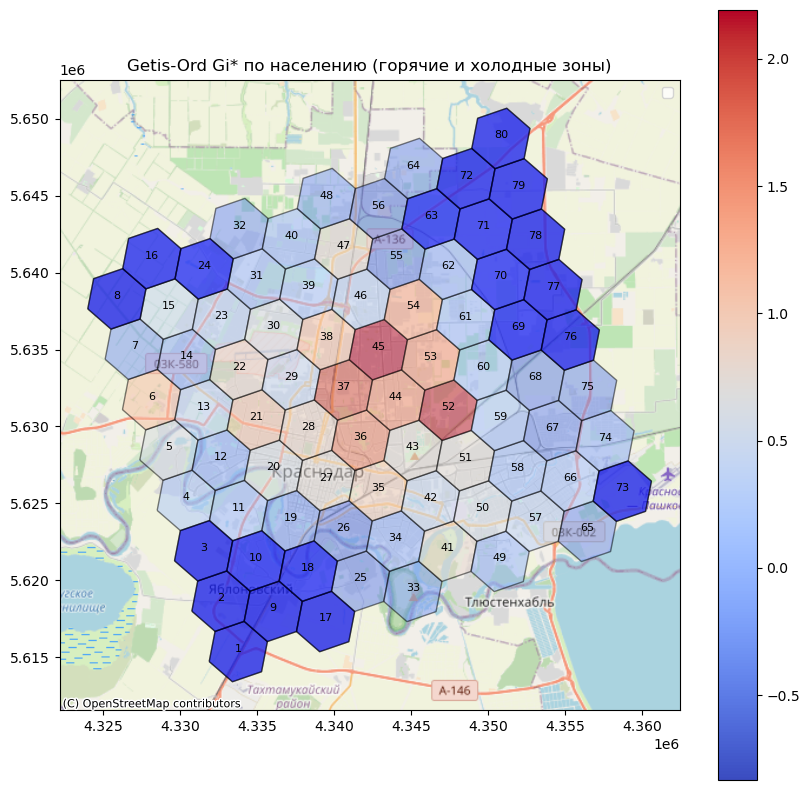

Удаляемые холодные зоны (ID): [1, 2, 3, 8, 9, 10, 16, 17, 18, 24, 63, 69, 70, 71, 72, 73, 76, 77, 78, 79, 80]


In [40]:

import libpysal as ps
import esda
import contextily as ctx


# Удаляем NaN в населении
hex_gdf["population"] = hex_gdf["population"].fillna(0)

#  матрица соседства (Queen contiguity)
w = ps.weights.Queen.from_dataframe(hex_gdf)
w.transform = 'r'  # Нормируем веса

# считаем статистику Getis-Ord Gi*
population_values = hex_gdf["population"].values
getis_ord = esda.G_Local(population_values, w)

hex_gdf["GiZScore"] = getis_ord.Zs

# Определяем холодные зоны (GiZScore < -0.5)
cold_zones = hex_gdf[hex_gdf["GiZScore"] < -0.5]
filtered_hex_gdf = hex_gdf[hex_gdf["GiZScore"] >= -0.5]

fig, ax = plt.subplots(figsize=(10, 10))
hex_gdf.plot(ax=ax, column="GiZScore", cmap="coolwarm", edgecolor="k",alpha=0.5, legend=True)
cold_zones.plot(ax=ax, color="blue", edgecolor="k", alpha=0.5, label="Холодные зоны")

# Добавляем id на гексагоны
for x, y, label in zip(hex_gdf.geometry.centroid.x, hex_gdf.geometry.centroid.y, hex_gdf["id"]):
    ax.text(x, y, str(label), fontsize=8, ha='center', color='black')

ctx.add_basemap(ax, crs=hex_gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
plt.legend()
plt.title("Getis-Ord Gi* по населению (горячие и холодные зоны)")
plt.show()

#  id холодных зон
print("Удаляемые холодные зоны (ID):", cold_zones["id"].tolist())


filtered_hex_gdf.to_file("krasnodar_hex_filtered.geojson", driver="GeoJSON")


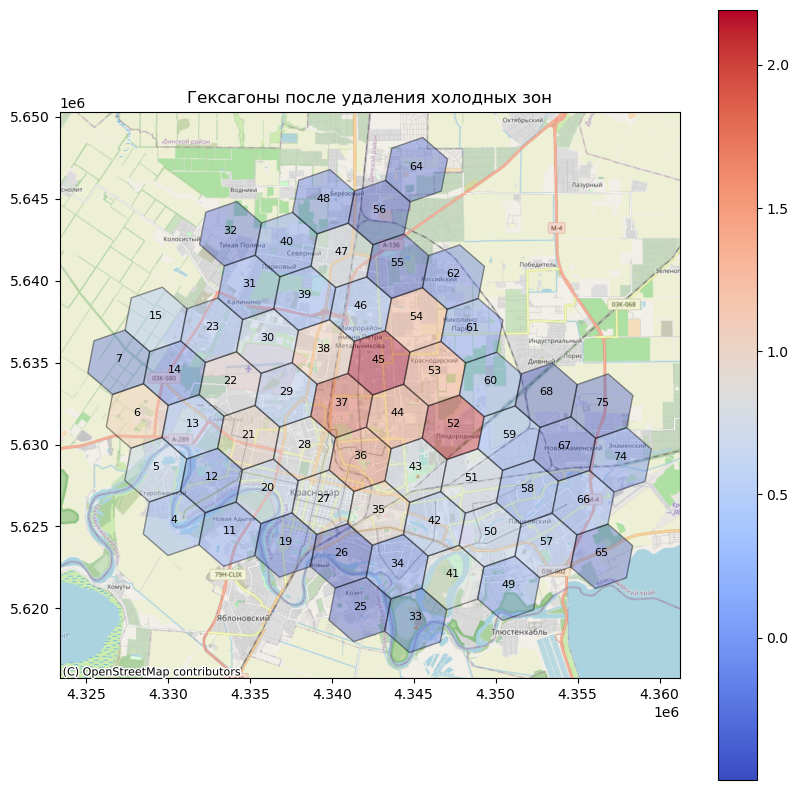

In [41]:
# Удаляем холодные зоны
filtered_hex_gdf = hex_gdf[~hex_gdf["id"].isin([1, 2, 3, 8, 9, 10, 16, 17, 18, 24, 63, 69, 70, 71, 72, 73, 76, 77, 78, 79, 80])]

#  
fig, ax = plt.subplots(figsize=(10, 10))
for x, y, label in zip(filtered_hex_gdf.geometry.centroid.x, filtered_hex_gdf.geometry.centroid.y, filtered_hex_gdf["id"]):
    ax.text(x, y, str(label), fontsize=8, ha='center', color='black')

# 
filtered_hex_gdf.plot(ax=ax, column="GiZScore", cmap="coolwarm", edgecolor="k", alpha=0.4, legend=True)


ctx.add_basemap(ax, crs=filtered_hex_gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

plt.title("Гексагоны после удаления холодных зон")
plt.show()

# 8️⃣ Сохраняем результат
filtered_hex_gdf.to_file("krasnodar_hex29_03_filtered.geojson", driver="GeoJSON")




In [42]:
print("Столбцы в pvz_gdf:")
print(pvz_gdf.columns)

print("\nСтолбцы в rent_gdf:")
print(rent_gdf.columns)

# Находим общие столбцы
common_columns = pvz_gdf.columns.intersection(rent_gdf.columns)
print("\nОбщие столбцы:")
print(common_columns)




Столбцы в pvz_gdf:
Index(['ID', 'Address', 'lat', 'long', 'population', 'Pedestrian traffic',
       'car traffic', 'poi_count', 'type', 'geometry'],
      dtype='object')

Столбцы в rent_gdf:
Index(['ID', 'Address', 'lat', 'long', 'square', 'rent_price', 'population',
       'poi_count', 'type', 'geometry'],
      dtype='object')

Общие столбцы:
Index(['ID', 'Address', 'lat', 'long', 'population', 'poi_count', 'type',
       'geometry'],
      dtype='object')


In [43]:
pvz_gdf_common = pvz_gdf[common_columns]
rent_gdf_common = rent_gdf[common_columns]


combined_gdf = pd.concat([pvz_gdf_common, rent_gdf_common], ignore_index=True)

print("\nОбъединенный DataFrame:")
print(combined_gdf.head())
combined_gdf.to_file("combined_pvz_rent29_03concat.geojson", driver="GeoJSON")


Объединенный DataFrame:
         ID                   Address        lat       long  population  \
0  50016316        Зелёная улица, 230  45.145918  39.051427      4200.0   
1    217006      Зелёная улица, 174\n  45.142911  39.045040      4200.0   
2    325506  Земляничная улица, 122\n  45.139224  39.032563      4200.0   
3    112779         Вишнёвая улица, 2  45.144678  39.038761      4200.0   
4    314626       Ореховая улица, 621  45.134188  39.019627     12000.0   

   poi_count type                         geometry  
0          0  pvz  POINT (4347184.968 5644522.615)  
1          0  pvz  POINT (4346473.971 5644048.027)  
2          0  pvz   POINT (4345085.038 5643466.15)  
3          0  pvz  POINT (4345774.996 5644326.906)  
4          1  pvz  POINT (4343645.009 5642671.436)  


In [44]:
import geopandas as gpd

combined_gdf = gpd.read_file("combined_pvz_rent29_03concat.geojson")

print(combined_gdf.columns)

# несколько строк для проверки данных
print(combined_gdf.head())


Index(['ID', 'Address', 'lat', 'long', 'population', 'poi_count', 'type',
       'geometry'],
      dtype='object')
         ID                   Address        lat       long  population  \
0  50016316        Зелёная улица, 230  45.145918  39.051427      4200.0   
1    217006      Зелёная улица, 174\n  45.142911  39.045040      4200.0   
2    325506  Земляничная улица, 122\n  45.139224  39.032563      4200.0   
3    112779         Вишнёвая улица, 2  45.144678  39.038761      4200.0   
4    314626       Ореховая улица, 621  45.134188  39.019627     12000.0   

   poi_count type                         geometry  
0          0  pvz  POINT (4347184.968 5644522.615)  
1          0  pvz  POINT (4346473.971 5644048.027)  
2          0  pvz   POINT (4345085.038 5643466.15)  
3          0  pvz  POINT (4345774.996 5644326.906)  
4          1  pvz  POINT (4343645.009 5642671.436)  


In [45]:

combined_gdf = combined_gdf.to_crs(hex_gdf.crs)

# Функция для поиска ID гексагона для каждой точки
def find_hexagon_id(point):
    # Ищем, в какой гексагон попадает точка
    for hex_id, hex_geometry in zip(hex_gdf["id"], hex_gdf["geometry"]):
        if hex_geometry.contains(point):
            return hex_id
    return None  

# Применяем функцию для добавления столбца с ID гексагона
combined_gdf["hex_id"] = combined_gdf.geometry.apply(find_hexagon_id)

# Удаляем строки, где нет ID гексагона
combined_gdf = combined_gdf.dropna(subset=["hex_id"])

# Сохраняем обновлённый датасет
combined_gdf.to_file("combined_with_hex_idFull_29_03.geojson", driver="GeoJSON")

# Выводим первые строки, чтобы проверить результат
print(combined_gdf.head())

         ID                   Address        lat       long  population  \
0  50016316        Зелёная улица, 230  45.145918  39.051427      4200.0   
1    217006      Зелёная улица, 174\n  45.142911  39.045040      4200.0   
2    325506  Земляничная улица, 122\n  45.139224  39.032563      4200.0   
3    112779         Вишнёвая улица, 2  45.144678  39.038761      4200.0   
4    314626       Ореховая улица, 621  45.134188  39.019627     12000.0   

   poi_count type                         geometry  hex_id  
0          0  pvz  POINT (4347184.968 5644522.615)      63  
1          0  pvz  POINT (4346473.971 5644048.027)      63  
2          0  pvz   POINT (4345085.038 5643466.15)      63  
3          0  pvz  POINT (4345774.996 5644326.906)      63  
4          1  pvz  POINT (4343645.009 5642671.436)      56  


In [39]:
import geopandas as gpd

combined_gdf = gpd.read_file("combined_with_hex_idFull_29_03.geojson")

In [40]:
combined_gdf.loc[combined_gdf['poi_count'] == 0, 'poi_count'] = 1
combined_gdf.to_file("combined_with_hex_idFull_05_04.geojson",driver="GeoJSON")


In [41]:
print(combined_gdf)

            ID                         Address        lat       long  \
0     50016316              Зелёная улица, 230  45.145918  39.051427   
1       217006            Зелёная улица, 174\n  45.142911  39.045040   
2       325506        Земляничная улица, 122\n  45.139224  39.032563   
3       112779               Вишнёвая улица, 2  45.144678  39.038761   
4       314626             Ореховая улица, 621  45.134188  39.019627   
...        ...                             ...        ...        ...   
1109      1200         Бородинская улица, 131А  45.012587  39.099685   
1110      1201  улица имени В.Н. Мачуги, 166/1  45.014836  39.094933   
1111      1202               улица Кирова, 198  45.021418  39.096074   
1112      1204               Крылатая улица, 2  45.011440  39.122574   
1113      1205            Криничная улица, 173  45.013294  39.118657   

      population  poi_count  type  hex_id                         geometry  
0         4200.0          1   pvz      63  POINT (4347184.

In [46]:
hex_ids_to_remove = [1, 2, 3, 8, 9, 10, 16, 17, 18, 24, 63, 69, 70, 71, 72, 73, 76, 77, 78, 79, 80]


combined_gdf = combined_gdf[~combined_gdf['hex_id'].isin(hex_ids_to_remove)]
combined_gdf.to_file("combined_with_hex_idFull_06_04.geojson",driver="GeoJSON")


In [49]:

from tqdm import tqdm
tqdm.pandas()


gdf = gpd.read_file("combined_with_hex_idFull_06_04.geojson").to_crs(epsg=3857)


poi = gpd.read_file("data/poi-point.geojson").to_crs(epsg=3857)

# 3. Классификация POI
def classify_poi(row):
    if pd.notna(row.get("amenity")):
        return "AMENITY"
    elif pd.notna(row.get("shop")):
        return "SHOP"
    elif pd.notna(row.get("office")):
        return "OFFICE"
    elif pd.notna(row.get("leisure")):
        return "LEISURE"
    elif pd.notna(row.get("tourism")):
        return "TOURISM"
    else:
        return None

poi["category"] = poi.apply(classify_poi, axis=1)
poi = poi.dropna(subset=["category"])

# функция подсчета POI рядом
def count_nearby(point, category):
    subset = poi[poi["category"] == category]
    return subset.distance(point).lt(200).sum()

# POI для каждой категории
for cat in ["AMENITY", "SHOP", "OFFICE", "LEISURE", "TOURISM"]:
    gdf[f"poi_{cat.lower()}"] = gdf.geometry.progress_apply(lambda g: count_nearby(g, cat))

output_path = "output_combined_with_POI_counts_200m.geojson"
gdf.to_file(output_path, driver="GeoJSON")




100%|██████████| 1049/1049 [00:00<00:00, 4710.44it/s]


In [50]:
import pandas as pd
import geopandas as gpd

#
points = gpd.read_file("output_combined_with_POI_counts_200m.geojson")

#hex-файл с населением и трафиком
hex_traffic = gpd.read_file("krasnodar_hex29_03_filtered.geojson")

# 
hex_traffic_clean = hex_traffic.rename(columns={
    "id": "hex_id",
    "car traffic": "car_traffic",
    "Pedestrian traffic": "foot_traffic"
})[["hex_id", "population", "car_traffic", "foot_traffic"]]

#  объединяем по hex_id
merged = points.merge(hex_traffic_clean, on="hex_id", how="left")
merged.to_file("points_with_POI_and_traffic.geojson", driver="GeoJSON")

print("сохранён как 'points_with_POI_and_traffic.geojson'")

сохранён как 'points_with_POI_and_traffic.geojson'


In [51]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

file_path = "points_with_POI_and_traffic.geojson"
final_points = gpd.read_file(file_path)

# Отбираем только ПВЗ
all_points = final_points.copy()

# привлекательность с учётом POI и установленных весов
all_points["attractiveness"] = (
    0.4 * all_points["poi_amenity"] +
    0.3 * all_points["poi_shop"] +
    0.2 * all_points["poi_office"] +
    0.05 * all_points["poi_leisure"] +
    0.05 * all_points["poi_tourism"]
)

full_output_path = "all_points_with_attractiveness.geojson"
all_points.to_file(full_output_path, driver="GeoJSON")

In [53]:
import geopandas as gpd
from shapely.geometry import Point

# Загрузка исходных данных
points = gpd.read_file("all_points_with_attractiveness.geojson").to_crs(epsg=3857)
stops = gpd.read_file("data/public-transport-point.geojson").to_crs(epsg=3857)

points = points[points.geometry.type == "Point"]

#  Создание буферов радиусом 300 метров
points["buffer"] = points.geometry.buffer(300)

#  Подсчёт количества остановок внутри 
points["poi_transport"] = points["buffer"].apply(
    lambda buf: stops.intersects(buf).sum()
)

points = points.drop(columns=["buffer"])

points.to_file("points_with_transport_count.geojson", driver="GeoJSON")

print(" 'points_with_transport_count.geojson'")

 'points_with_transport_count.geojson'


In [ ]:
import geopandas as gpd
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from libpysal import weights
from esda.moran import Moran
import matplotlib.pyplot as plt
import contextily as ctx


gdf = gpd.read_file("all_points_final_attractiveness.geojson")
gdf = gdf.to_crs(epsg=3857)
columns_of_interest = ["foot_traffic", "poi_amenity", "poi_shop", "poi_office"]


gdf = gdf.dropna(subset=columns_of_interest)

# Подготовка данных
X = gdf[["poi_amenity", "poi_shop", "poi_office"]].values
y = gdf["foot_traffic"].values.reshape((-1, 1))
coords = np.column_stack((gdf.geometry.x.values, gdf.geometry.y.values))

#определение оптимального bandwidth
bw = Sel_BW(coords, y, X).search()

# Построение GWR-модели
model = GWR(coords, y, X, bw)
results = model.fit()


n_vars = results.params.shape[1]
all_vars = ["amenity", "shop", "office"]
used_vars = all_vars[:n_vars]


for i, var in enumerate(used_vars):
    gdf[f"coef_{var}"] = results.params[:, i]

#  Добавляем метрики качества
gdf["predicted"] = results.predy.flatten()
gdf["residuals"] = (results.predy.flatten() - y.flatten())
gdf["local_R2"] = results.localR2

gdf.to_file("gwr_results_with_residuals.geojson", driver="GeoJSON")
print(" GWR-модель с остатками и R².")

# анализ остатков через Moran's I
gdf = gpd.read_file("gwr_results_with_residuals.geojson")
w = weights.KNN.from_dataframe(gdf, k=8)
w.transform = 'r'
moran = Moran(gdf["residuals"], w)

print("\n Moran's I результаты:")
print(f"Moran's I: {moran.I:.4f}")
print(f"p-value: {moran.p_sim:.4f}")
print(f"z-score: {moran.z_sim:.4f}")




 GWR-модель с остатками и R².

 Moran's I результаты:
Moran's I: 0.1890
p-value: 0.0010
z-score: 13.2709


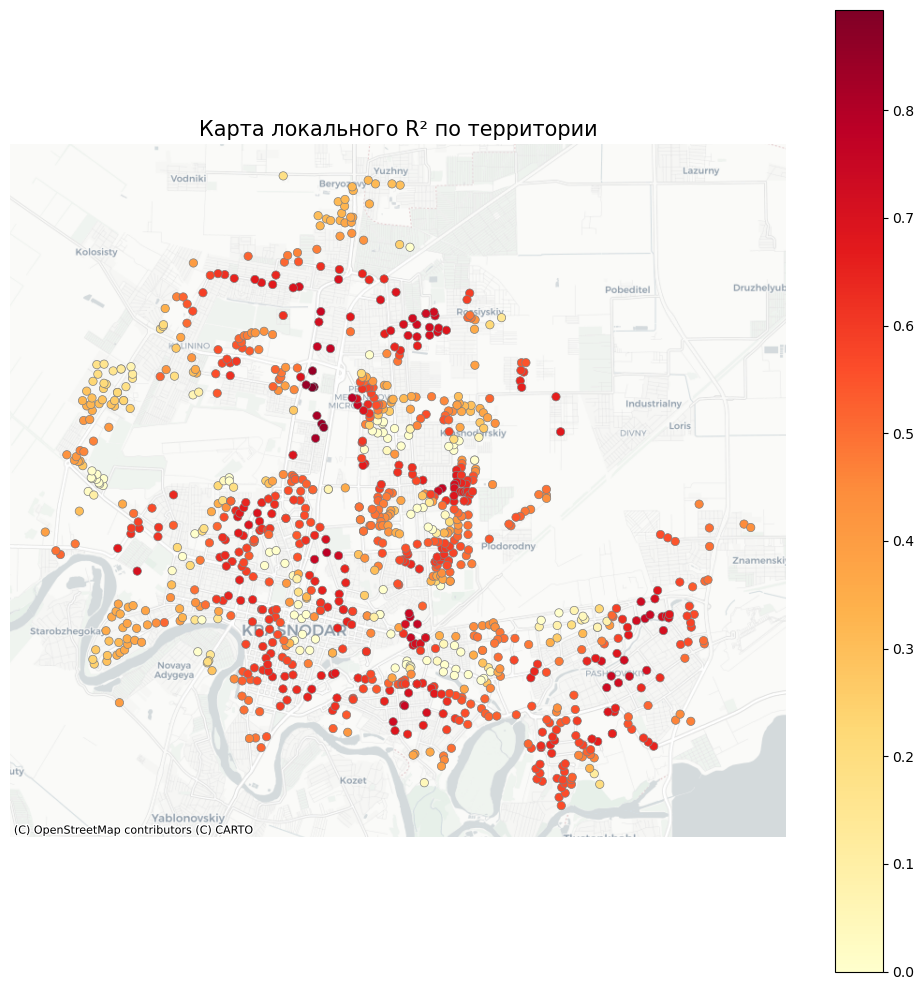

 Глобальный R² модели GWR: 0.8900
 Глобальный скорректированный R² модели GWR: 0.8668


In [56]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW


gdf = gpd.read_file("all_points_final_attractiveness_19_04_23_12.geojson")
gdf = gdf.to_crs(epsg=3857)

gdf = gdf.dropna(subset=["foot_traffic", "poi_amenity", "poi_shop", "poi_office"])


X = gdf[["poi_amenity", "poi_shop", "poi_office"]].values
y = gdf["foot_traffic"].values.reshape((-1, 1))
u = gdf.geometry.x.values
v = gdf.geometry.y.values
coords = np.column_stack((u, v))


bw = Sel_BW(coords, y, X).search()

model = GWR(coords, y, X, bw)
results = model.fit()


gdf["local_R2"] = results.localR2.clip(0, 1)  # ограничение от 0 до 1
gdf["predictions"] = results.predy.flatten()
gdf["residuals"] = (y.flatten() - results.predy.flatten())

for i, var in enumerate(["amenity", "shop", "office"]):
    gdf[f"coef_{var}"] = results.params[:, i]

gdf.to_file("gwr_results_full.geojson", driver="GeoJSON")

# визуализация карты локального R²
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column="local_R2", cmap="YlOrRd", linewidth=0.5, edgecolor='grey', legend=True, ax=ax)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Карта локального R² по территории", fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.savefig("gwr_local_r2_full.png", dpi=300)
plt.show()


print(f" Глобальный R² модели GWR: {results.R2:.4f}")
print(f" Глобальный скорректированный R² модели GWR: {results.adj_R2:.4f}")

In [ ]:
import geopandas as gpd
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import numpy as np


gdf = gpd.read_file("all_points_final_attractiveness.geojson")
gdf = gdf.to_crs(epsg=3857)


gdf = gdf.dropna(subset=["foot_traffic"])
X = gdf[["poi_amenity", "poi_shop", "poi_office"]].values
y = gdf["foot_traffic"].values.reshape((-1, 1))


u = gdf.geometry.x.values
v = gdf.geometry.y.values
coords = np.column_stack((u, v))


bw = Sel_BW(coords, y, X).search()

model = GWR(coords, y, X, bw)
results = model.fit()

for i, var in enumerate(["amenity", "shop", "office"]):
    gdf[f"coef_{var}"] = results.params[:, i]

gdf.to_file("gwr_results_amenity_shop_office.geojson", driver="GeoJSON")

print("Упрощённая GWR-модель.")


Упрощённая GWR-модель.


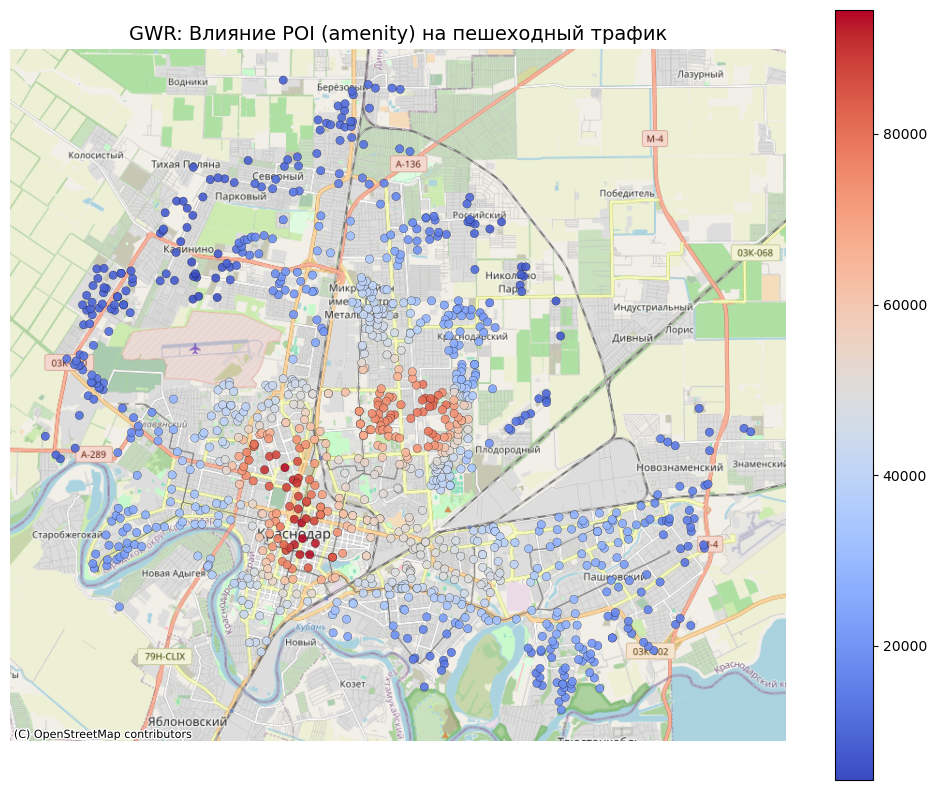

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

gwr_results = gpd.read_file("gwr_results_amenity_shop_office.geojson").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
gwr_results.plot(
    column="coef_amenity", cmap="coolwarm", legend=True,
    edgecolor="black", linewidth=0.2, alpha=0.9, ax=ax
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gwr_results.crs)
plt.title("GWR: Влияние POI (amenity) на пешеходный трафик", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


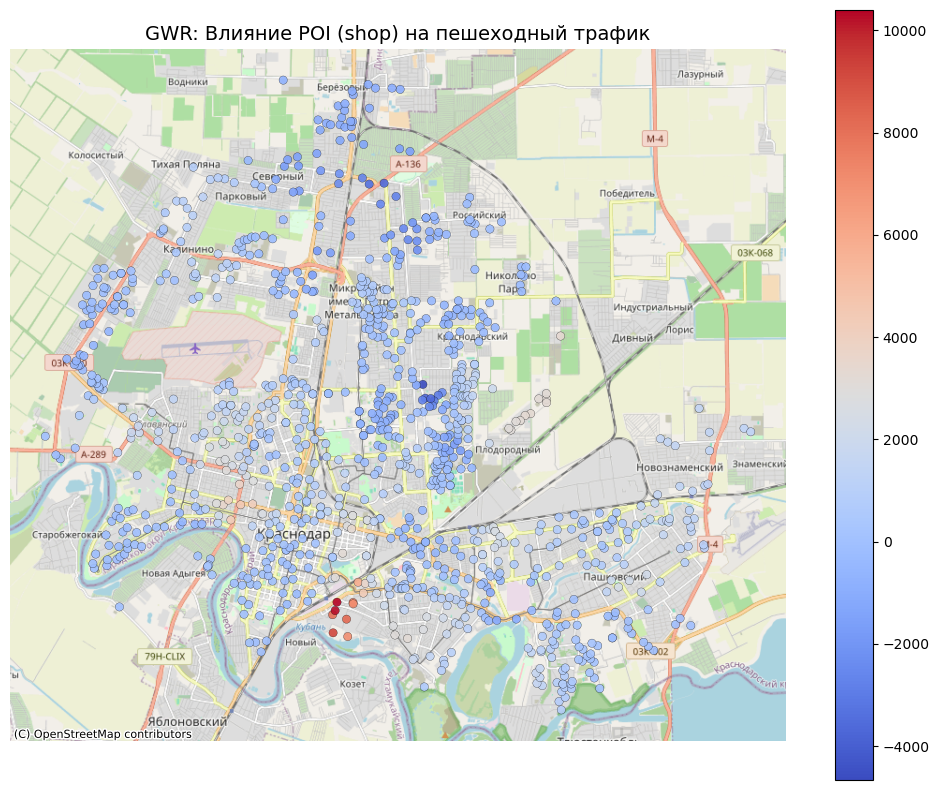

In [58]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx


gdf = gpd.read_file("gwr_results_amenity_shop_office.geojson").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(
    column="coef_shop", cmap="coolwarm", legend=True,
    edgecolor="black", linewidth=0.2, alpha=0.9, ax=ax
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf.crs)
plt.title("GWR: Влияние POI (shop) на пешеходный трафик", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


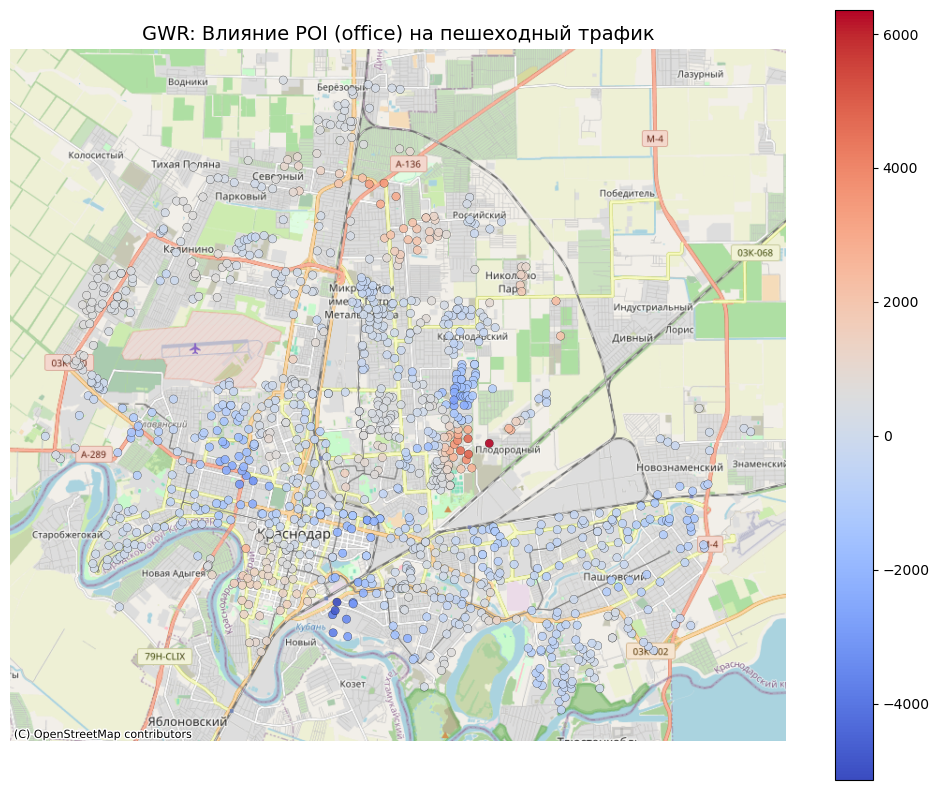

In [59]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx


gdf = gpd.read_file("gwr_results_amenity_shop_office.geojson").to_crs(epsg=3857)


fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column="coef_office", cmap="coolwarm", legend=True,
             edgecolor="black", linewidth=0.2, alpha=0.9, ax=ax)


ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf.crs)
plt.title("GWR: Влияние POI (office) на пешеходный трафик", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [60]:
transport_enriched = gpd.read_file("points_with_transport_count.geojson")


columns = transport_enriched.columns.tolist()
sample = transport_enriched.head(3)
transport_enriched["attractiveness_updated"] = (
    0.35 * transport_enriched["poi_amenity"] +
    0.25 * transport_enriched["poi_shop"] +
    0.2  * transport_enriched["poi_office"] +
    0.1  * transport_enriched["poi_transport"] +
    0.05 * transport_enriched["poi_leisure"] +
    0.05 * transport_enriched["poi_tourism"]
)

updated_path = "all_points_with_updated_attractiveness.geojson"
transport_enriched.to_file(updated_path, driver="GeoJSON")

In [61]:
transport_enriched["attractiveness_updated"] = transport_enriched["attractiveness_updated"].apply(
    lambda val: 0.05 if val == 0 else val
)

#  исправленный файл
corrected_path = "all_points_with_updated_attractiveness_min0_05.geojson"
transport_enriched.to_file(corrected_path, driver="GeoJSON")

In [62]:
unique_attractiveness = sorted(transport_enriched["attractiveness_updated"].unique())
small_values = [val for val in unique_attractiveness if val <= 0.05]

In [63]:

transport_enriched = transport_enriched.drop(columns=["attractiveness"])
transport_enriched = transport_enriched.rename(columns={"attractiveness_updated": "attractiveness"})

final_attr_path = "all_points_final_attractiveness.geojson"
transport_enriched.to_file(final_attr_path, driver="GeoJSON")

In [64]:
import geopandas as gpd

points_with_attr = gpd.read_file("all_points_final_attractiveness.geojson")

# вычисление центров гексагонов по hex_id
hex_centers = points_with_attr.dissolve(by="hex_id").copy()
hex_centers["hex_center"] = hex_centers.centroid


hex_centers_gdf = gpd.GeoDataFrame(
    hex_centers.reset_index()[["hex_id", "hex_center"]],
    geometry="hex_center",
    crs=points_with_attr.crs
)

# Сохраняем центры гексагонов
hex_centers_path = "hex_centers.geojson"
hex_centers_gdf.to_file(hex_centers_path, driver="GeoJSON")

In [66]:
from geopy.distance import geodesic


# Загрузка данных
points = gpd.read_file("all_points_final_attractiveness.geojson").to_crs(epsg=4326)
hex_centers = gpd.read_file("hex_centers.geojson").to_crs(epsg=4326)

#   дорожная сеть
G = ox.graph_from_place("Krasnodar, Russia", network_type="drive")

#   функция поиска ближайшей вершины
def get_nearest_node(point):
    return ox.distance.nearest_nodes(G, point.x, point.y)

# результаты
results = []

#  расчёт расстояний только для точек внутри каждого гексагона
for _, hex_row in tqdm(hex_centers.iterrows(), total=len(hex_centers), desc="Hex"):
    hex_id = hex_row["hex_id"]
    center_point = hex_row.geometry
    center_node = get_nearest_node(center_point)

    # Точки, относящиеся к этому гексагону
    local_points = points[points["hex_id"] == hex_id]

    for _, pt in local_points.iterrows():
        point_id = pt["ID"]
        target_point = pt.geometry
        try:
            target_node = get_nearest_node(target_point)
            length = nx.shortest_path_length(G, center_node, target_node, weight="length")
            if length <= 50:
                distance = 0.01
            else:
                distance = length
        except:
            # если не соединились — эвклид + 150
            eucl = geodesic((center_point.y, center_point.x), (target_point.y, target_point.x)).meters
            distance = eucl + 150

        results.append({
            "hex_id": hex_id,
            "point_id": point_id,
            "distance_m": round(distance, 2)
        })

# результаты
df = pd.DataFrame(results)

df.to_csv("local_hex_point_distances.csv", index=False)

print(" сохранено в 'local_hex_point_distances.csv'")

/Users/arslan/anaconda3/envs/geo_env2/lib/python3.11/site-packages/osmnx/_overpass.py:267: UserWarning: This area is 46 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)
Hex: 100%|██████████| 55/55 [08:24<00:00,  9.18s/it]

 сохранено в 'local_hex_point_distances.csv'


In [67]:

local_distances = df


points = gpd.read_file("all_points_final_attractiveness.geojson")


points["ID"] = points["ID"].astype(int)


merged = local_distances.merge(points[["ID", "attractiveness"]], left_on="point_id", right_on="ID", how="left")

# Добавим параметр λ
lambda_val = 1.5

# Вычисляем A_j / D_ij^λ
merged["huff_numerator"] = merged["attractiveness"] / merged["distance_m"]**lambda_val

# группируем по hex_id и нормализуем — получаем P_ij
merged["P_ij"] = merged.groupby("hex_id")["huff_numerator"].transform(lambda x: x / x.sum())

pij_output = merged[["hex_id", "point_id", "P_ij"]]
pij_csv_path = "huff_probabilities_lambda1_5.csv"
pij_output.to_csv(pij_csv_path, index=False)

In [68]:
# грузим население из файла с точками
population_by_hex = points[["hex_id", "population_y"]].drop_duplicates().rename(columns={"population_y": "population"})

# объединям с вероятностями
pij_with_pop = pij_output.merge(population_by_hex, on="hex_id", how="left")

# ожидаемый спрос
pij_with_pop["expected_demand"] = pij_with_pop["P_ij"] * pij_with_pop["population"]

demand_path = "huff_expected_demand.csv"
pij_with_pop.to_csv(demand_path, index=False)

In [69]:
import pandas as pd
import geopandas as gpd
import numpy as np


distances_df = pd.read_csv("local_hex_point_distances.csv")
points = gpd.read_file("all_points_final_attractiveness.geojson")


points["ID"] = points["ID"].astype(int)


merged = distances_df.merge(points[["ID", "attractiveness"]], left_on="point_id", right_on="ID", how="left")

#  Параметры модели
lambda_val = 0.7

#  Расчёт числителя модели Хаффа
merged["huff_numerator"] = merged["attractiveness"] / merged["distance_m"]**lambda_val

#  Нормализация по hex_id → расчёт вероятностей
merged["P_ij"] = merged.groupby("hex_id")["huff_numerator"].transform(lambda x: x / x.sum())

#  Добавим население гексагонов (из points)
population_df = points[["hex_id", "population_y"]].drop_duplicates().rename(columns={"population_y": "population"})
merged = merged.merge(population_df, on="hex_id", how="left")

#. Ожидаемый спрос: S_ij = P_ij × N_i
merged["expected_demand"] = merged["P_ij"] * merged["population"]

#  Сохраним подробный файл
merged[["hex_id", "point_id", "P_ij", "expected_demand"]].to_csv("huff_probabilities_demand.csv", index=False)

# Агрегация спроса по точке
total_demand = merged.groupby("point_id")["expected_demand"].sum().reset_index()

#  Добавим типы, hex_id, привлекательность обратно
point_info = points[["ID", "type", "hex_id", "attractiveness"]].rename(columns={"ID": "point_id"})
total_demand = total_demand.merge(point_info, on="point_id", how="left")

#  Отбор топ-15 арендных локаций
top_rent = total_demand[total_demand["type"] == "rent"].sort_values(by="expected_demand", ascending=False).head(15)


total_demand.to_csv("total_expected_demand_by_point.csv", index=False)
top_rent.to_csv("top_15_rent_locations.csv", index=False)

print(" шаги модели Хаффа выполнены и результаты сохранены.")

 шаги модели Хаффа выполнены и результаты сохранены.


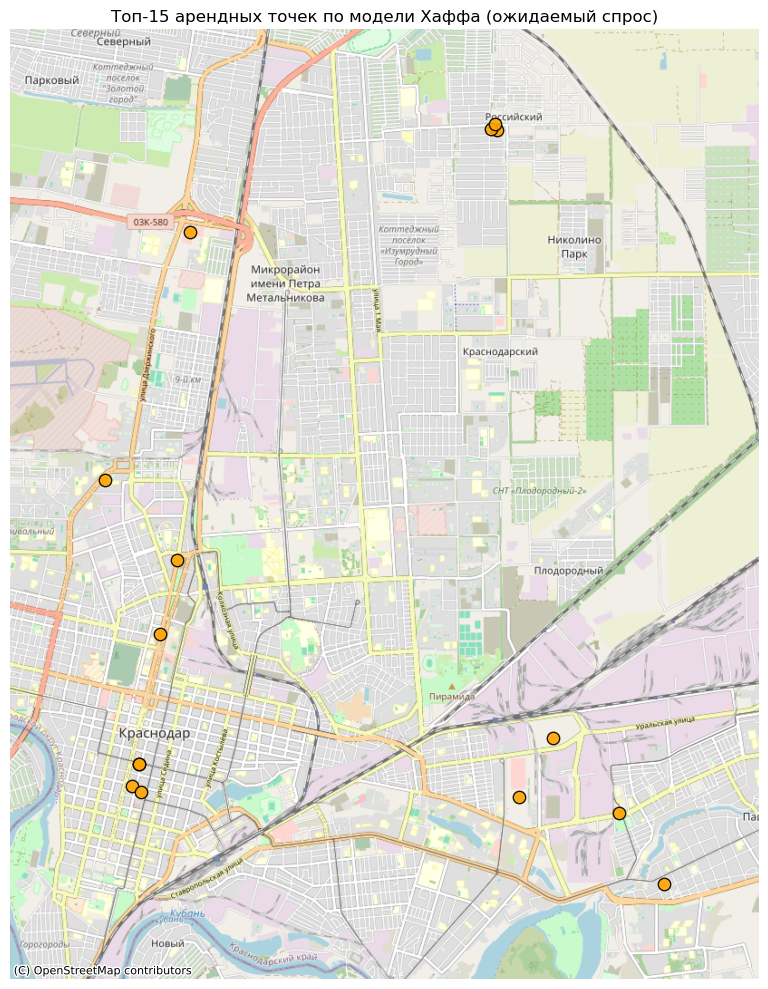

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd


points = gpd.read_file("all_points_final_attractiveness.geojson").to_crs(epsg=3857)

top_rent = pd.read_csv("top_15_rent_locations.csv")

#  Отбор соответствующих точек по ID
top_rent_points = points[points["ID"].isin(top_rent["point_id"])]

#  Визуализация
fig, ax = plt.subplots(figsize=(10, 10))


top_rent_points.plot(ax=ax, markersize=80, color="orange", edgecolor="black", alpha=0.9)


buffer = 2000 
xmin, ymin, xmax, ymax = top_rent_points.total_bounds
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)


ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=top_rent_points.crs)


plt.title("Топ-15 арендных точек по модели Хаффа (ожидаемый спрос)")
plt.axis("off")
plt.tight_layout()
plt.show()

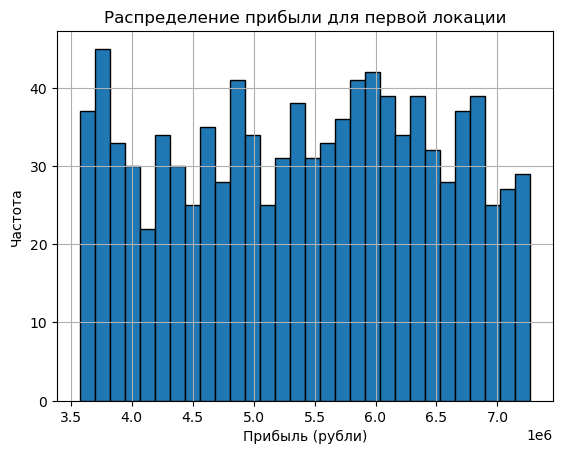

{'Средняя прибыль (руб.)': np.float64(5419300.913451376),
 'Стандартное отклонение прибыли (руб.)': np.float64(1057620.467749266),
 'Вероятность положительной прибыли (%)': np.float64(100.0)}

In [71]:
import numpy as np
import matplotlib.pyplot as plt
#По топ локациям подготовил по карте данные по прогнозируемому товарообороту 
file_path = 'top_locations_with_predictions - top_15_rent_locations.csv'
df = pd.read_csv(file_path)
# Настройки Монте карло
n_simulations = 1000  # количество симуляций

sample_location = df.iloc[0]

#  фиксированные параметры
rent = sample_location['Арендная плата']
salary = sample_location['Оплата труда']
other_expenses = sample_location['Другие траты']

# диапазон прогнозируемого товарооборота
revenue_min = sample_location['Прогнозируемый товарооборот в первый месяц']
revenue_max = sample_location['Прогнозируемый товарооборот через 5 месяцев']

# Моделируем товарооборот 
simulated_revenues = np.random.uniform(revenue_min, revenue_max, n_simulations)

# расчет прибыли: Товарооборот - (аренда + зарплата + прочие расходы)
simulated_profits = simulated_revenues - (rent + salary + other_expenses)

# основные метрики
mean_profit = np.mean(simulated_profits)
std_profit = np.std(simulated_profits)
positive_profit_prob = np.mean(simulated_profits > 0)

# Результаты
analysis_result = {
    "Средняя прибыль (руб.)": mean_profit,
    "Стандартное отклонение прибыли (руб.)": std_profit,
    "Вероятность положительной прибыли (%)": positive_profit_prob * 100
}

# распределение прибыли
plt.hist(simulated_profits, bins=30, edgecolor='black')
plt.title('Распределение прибыли для первой локации')
plt.xlabel('Прибыль (рубли)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

analysis_result

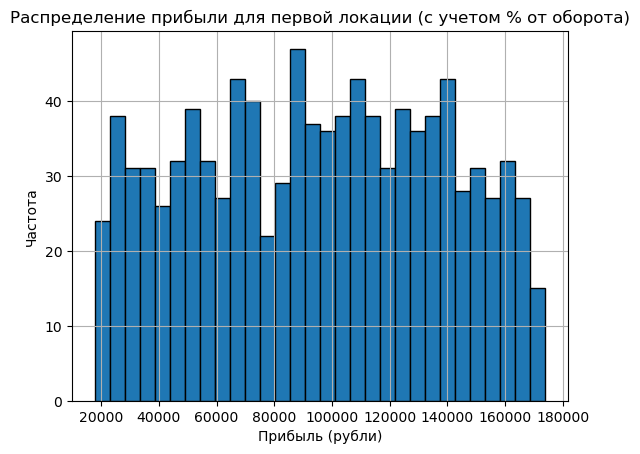

{'Средняя прибыль (руб.)': np.float64(95080.53801425942),
 'Стандартное отклонение прибыли (руб.)': np.float64(42629.813480466204),
 'Вероятность положительной прибыли (%)': np.float64(100.0)}

In [72]:
percent_min = 0.039  # 3.9%
percent_max = 0.041  # 4.1%

# Смоделируем товарооборот и процент дохода
simulated_revenues = np.random.uniform(revenue_min, revenue_max, n_simulations)
simulated_income_percentages = np.random.uniform(percent_min, percent_max, n_simulations)

# расчет реальной выручки (дохода)
simulated_incomes = simulated_revenues * simulated_income_percentages

#  расчет прибыли
simulated_profits_corrected = simulated_incomes - (rent + salary + other_expenses)

# пересчитаем метрики
mean_profit_corr = np.mean(simulated_profits_corrected)
std_profit_corr = np.std(simulated_profits_corrected)
positive_profit_prob_corr = np.mean(simulated_profits_corrected > 0)

# новое распределение прибыли
plt.hist(simulated_profits_corrected, bins=30, edgecolor='black')
plt.title('Распределение прибыли для первой локации (с учетом % от оборота)')
plt.xlabel('Прибыль (рубли)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

# Новый результат
corrected_analysis_result = {
    "Средняя прибыль (руб.)": mean_profit_corr,
    "Стандартное отклонение прибыли (руб.)": std_profit_corr,
    "Вероятность положительной прибыли (%)": positive_profit_prob_corr * 100
}

corrected_analysis_result

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = 'top_locations_with_predictions - top_15_rent_locations.csv'
df = pd.read_csv(file_path)

# Настройки
n_simulations = 1000
investment_cost = 600000  # фиксированные инвестиции
monthly_revenue_fluctuation = 0.05  # 5% колебания
percent_min = 0.039  # 3.9%
percent_max = 0.041  # 4.1%

updated_results = []

for idx, row in df.iterrows():
    rent = row['Арендная плата']
    salary = row['Оплата труда']
    other_expenses = row['Другие траты']
    
    revenue_min = row['Прогнозируемый товарооборот в первый месяц']
    revenue_max = row['Прогнозируемый товарооборот через 5 месяцев']
    
    yearly_profits = []
    
    for _ in range(n_simulations):
        monthly_profits = []
        
        # Месяцы 1–5: рост товарооборота
        for month in range(1, 6):
            trend_revenue = revenue_min + (revenue_max - revenue_min) * (month - 1) / 4
            fluctuation = np.random.uniform(1 - monthly_revenue_fluctuation, 1 + monthly_revenue_fluctuation)
            simulated_revenue = trend_revenue * fluctuation
            margin = np.random.uniform(percent_min, percent_max)
            income = simulated_revenue * margin
            monthly_profit = income - (rent + salary + other_expenses)
            monthly_profits.append(monthly_profit)
        
        # Месяцы 6–12: стабильный оборот вокруг revenue_max
        for _ in range(6, 13):
            fluctuation = np.random.uniform(1 - monthly_revenue_fluctuation, 1 + monthly_revenue_fluctuation)
            simulated_revenue = revenue_max * fluctuation
            margin = np.random.uniform(percent_min, percent_max)
            income = simulated_revenue * margin
            monthly_profit = income - (rent + salary + other_expenses)
            monthly_profits.append(monthly_profit)
        
        # Годовая прибыль за вычетом инвестиций
        annual_profit = sum(monthly_profits) - investment_cost
        yearly_profits.append(annual_profit)
    
    # Метрики по симуляциям
    mean_annual_profit = np.mean(yearly_profits)
    std_annual_profit = np.std(yearly_profits)
    prob_positive_profit = np.mean(np.array(yearly_profits) > 0) * 100
    
    updated_results.append({
        "point_id": row.get('point_id', f"point_{idx}"),
        "address": row.get('адрес', 'unknown'),
        "Средняя годовая прибыль (руб.)": round(mean_annual_profit, 0),
        "Стандартное отклонение прибыли (руб.)": round(std_annual_profit, 0),
        "Вероятность положительной прибыли (%)": round(prob_positive_profit, 2)
    })


updated_results_df = pd.DataFrame(updated_results)

# Показываем топ-5
print(updated_results_df.sort_values(by="Средняя годовая прибыль (руб.)", ascending=False).head())

updated_results_df.to_csv("profit_simulation_results.csv", index=False)


    point_id                        address  Средняя годовая прибыль (руб.)  \
0       1013  улица имени В.М. Комарова, 90                       1044192.0   
5       1086     улица имени Тургенева, 164                        480256.0   
1       1014   улица Академика Королёва, 22                        463081.0   
9       1112            улица Горького, 104                        304479.0   
14      1189              Краевая улица, 10                         79902.0   

    Стандартное отклонение прибыли (руб.)  \
0                                 29913.0   
5                                 25036.0   
1                                 22357.0   
9                                 19970.0   
14                                18492.0   

    Вероятность положительной прибыли (%)  
0                                   100.0  
5                                   100.0  
1                                   100.0  
9                                   100.0  
14                                

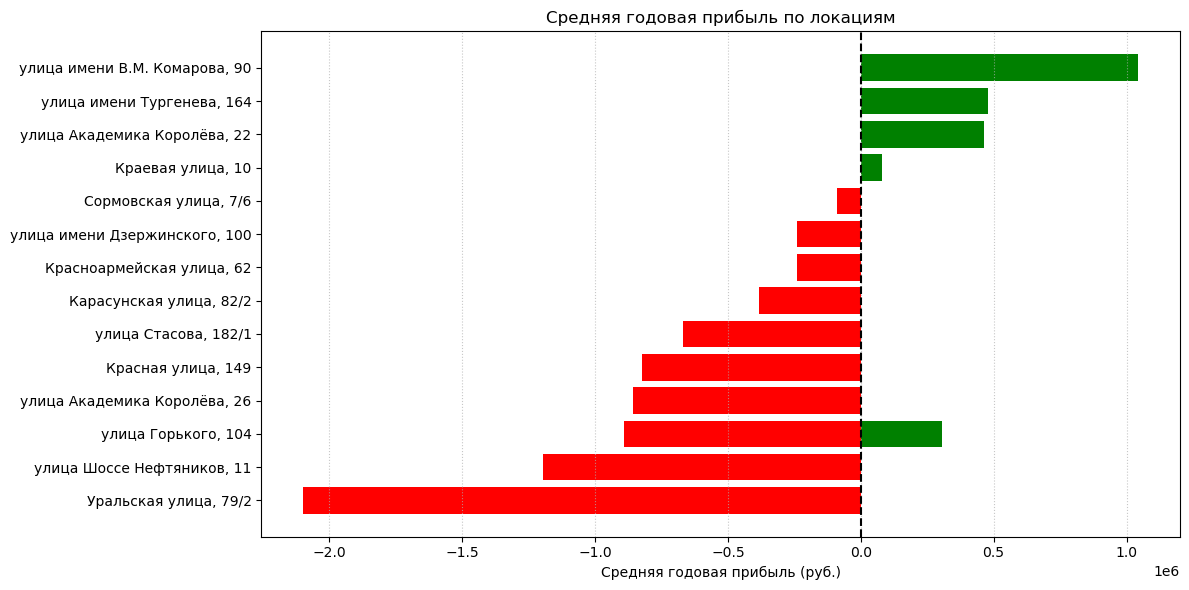

In [74]:
import matplotlib.pyplot as plt

# Сортировка для наглядности
df_sorted = updated_results_df.sort_values(by="Средняя годовая прибыль (руб.)")

# ГРАФИК 1: Средняя годовая прибыль
plt.figure(figsize=(12, 6))
plt.barh(df_sorted['address'], df_sorted["Средняя годовая прибыль (руб.)"],
         color=df_sorted["Средняя годовая прибыль (руб.)"].apply(lambda x: 'green' if x > 0 else 'red'))
plt.xlabel("Средняя годовая прибыль (руб.)")
plt.title("Средняя годовая прибыль по локациям")
plt.axvline(0, color='black', linestyle='--')
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

